In [32]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch

import celltypist
from celltypist import models

/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [4]:
scvi.settings.seed = 0

Seed set to 0


In [5]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
#save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [2]:
counts = pd.read_csv("counts_matrix.tsv", sep="\t", index_col=0)
meta = pd.read_csv("metadata.tsv", sep="\t", index_col=0)

adata = sc.AnnData(counts.T)
adata.obs = meta

In [7]:
adata

AnnData object with n_obs × n_vars = 4645 × 21778
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'tumor_cells', 'malignant', 'cell_type', 'percent.mt'
    var: 'n_counts'

In [6]:
sc.pp.filter_genes(adata, min_counts=3)

In [12]:
adata.var["mt"] = adata.var_names.str.startswith("MT")

In [13]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS","RPL"))

In [15]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt","ribo"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [17]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,tumor_cells,malignant,cell_type,percent.mt,_scvi_batch,_scvi_labels,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
Cy72_CD45_H02_S758_comb,SeuratProject,7143.362525,3365,Mel_72,non_malignant,B_cell,0.895656,0,0,135,276.082886,7.638972,2.766913,22.512506,8.154257
CY58_1_CD45_B02_S974_comb,SeuratProject,8915.833116,3637,Mel_58,non_malignant,T_cell,0.787243,0,0,198,370.710632,6.453724,1.740906,13.467625,3.632921
Cy71_CD45_D08_S524_comb,SeuratProject,12578.256217,4660,Mel_71,malignant,unknown,0.620160,0,0,239,357.644531,5.510196,1.540691,19.989609,5.589239
Cy81_FNA_CD45_B01_S301_comb,SeuratProject,16763.657866,6387,Mel_81,malignant,unknown,0.813499,0,0,341,430.663025,9.174239,2.130259,12.821646,2.977188
Cy80_II_CD45_B07_S883_comb,SeuratProject,16326.734878,5913,Mel_80,malignant,unknown,0.792611,0,0,341,428.512146,8.182685,1.909557,12.927044,3.016728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CY75_1_CD45_CD8_7__S223_comb,SeuratProject,11474.259370,5385,Mel_75,non_malignant,T_cell,0.788003,0,0,261,411.801270,6.689479,1.624444,15.237141,3.700120
CY75_1_CD45_CD8_1__S65_comb,SeuratProject,10071.714407,4769,Mel_75,non_malignant,T_cell,0.980667,0,0,217,368.997894,8.949509,2.425355,15.562497,4.217503
CY75_1_CD45_CD8_1__S93_comb,SeuratProject,10088.592439,4727,Mel_75,non_malignant,T_cell,0.878210,0,0,226,384.889404,10.765183,2.796955,14.653509,3.807200
CY75_1_CD45_CD8_1__S76_comb,SeuratProject,9881.552435,4976,Mel_75,non_malignant,T_cell,0.974551,0,0,219,387.111938,9.802192,2.532134,16.877571,4.359869


In [8]:
adata.layers["counts"] = adata.X.copy()  # preserve counts
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # freeze the state in `.raw`

In [10]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="tumor_cells",
)

In [18]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    categorical_covariate_keys=["tumor_cells", "malignant"],
    continuous_covariate_keys=["pct_counts_mt", "pct_counts_ribo"],
)

In [19]:
model = scvi.model.SCVI(adata)


In [20]:
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [21]:
model.train(train_size=0.8, check_val_every_n_epoch=1)


/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/lightning/pytorch

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [22]:
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(4645, 10)

In [23]:
denoised = model.get_normalized_expression(adata, library_size=1e4)
denoised.iloc[:5, :5]

,PNMA1,BRIX1,BANK1,CXCL13,SERPINF1
Cy72_CD45_H02_S758_comb,1.107212,1.475067,39.231773,0.048493,0.195512
CY58_1_CD45_B02_S974_comb,3.822206,3.586053,0.271525,8.308153,1.150906
Cy71_CD45_D08_S524_comb,3.910211,8.854189,0.152190,0.201342,16.107920
Cy81_FNA_CD45_B01_S301_comb,5.315982,32.633549,0.026817,0.832396,18.179552
Cy80_II_CD45_B07_S883_comb,6.677930,12.343309,0.451736,2.208565,6.685349


In [24]:
SCVI_NORMALIZED_KEY = "scvi_normalized"

adata.layers[SCVI_NORMALIZED_KEY] = model.get_normalized_expression(library_size=10e4)

In [25]:
# run PCA then generate UMAP plots
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

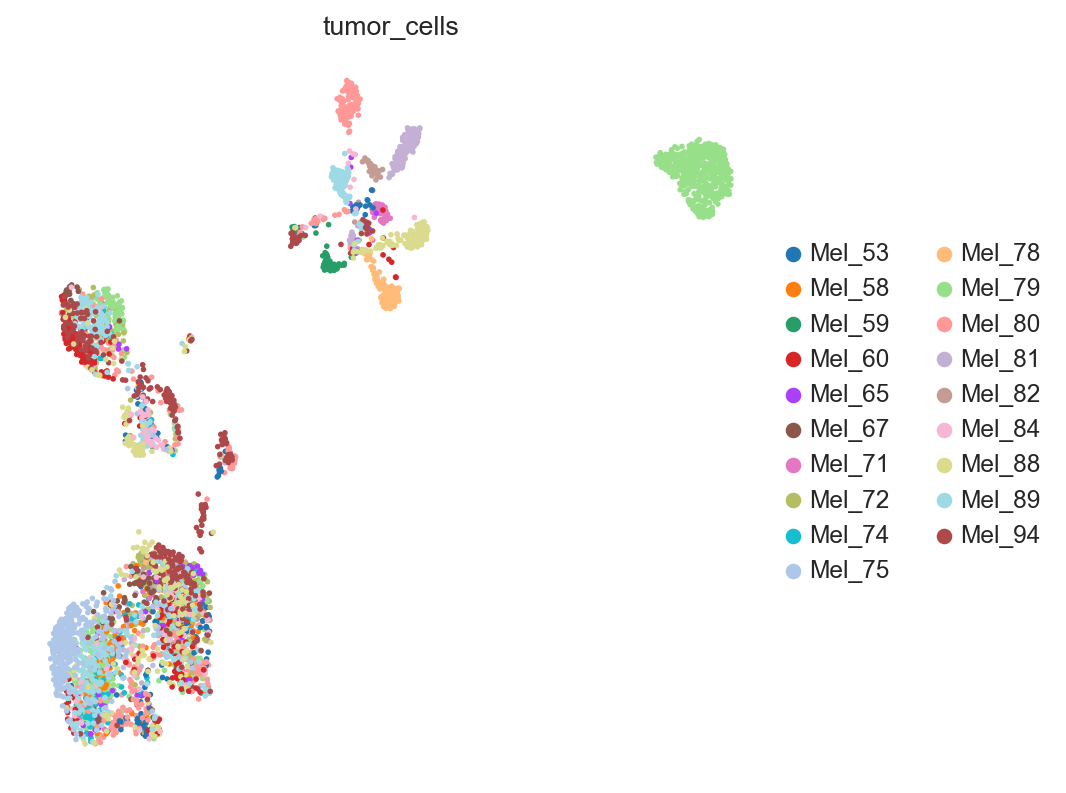

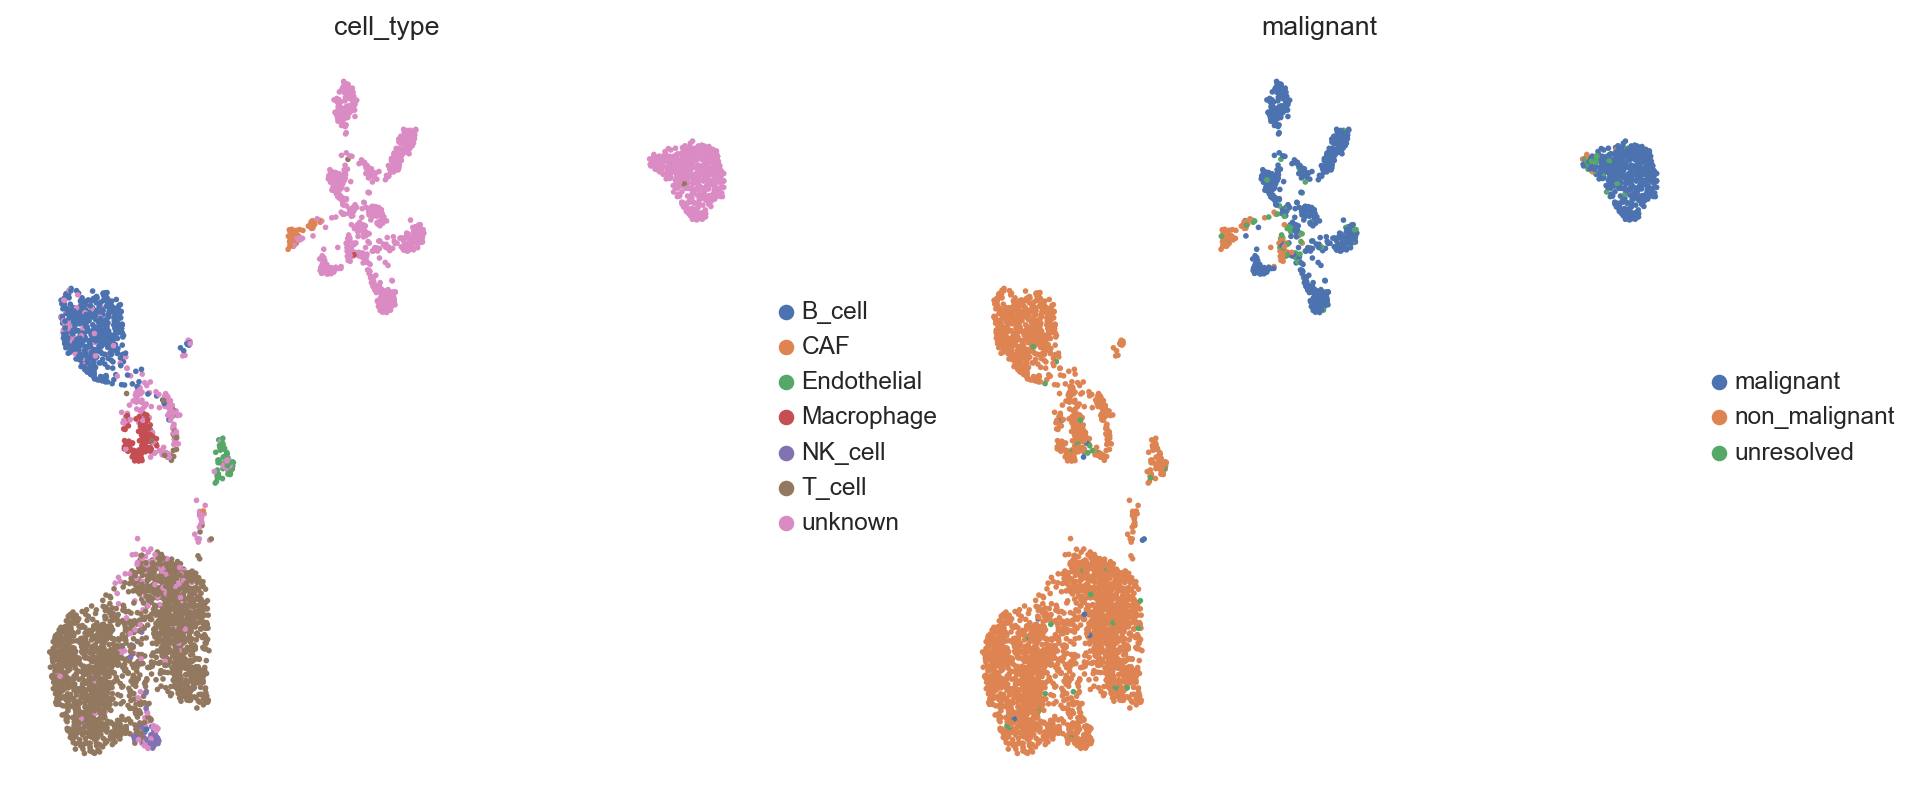

In [26]:
sc.pl.umap(
    adata,
    color=["tumor_cells"],
    frameon=False,
)
sc.pl.umap(
    adata,
    color=["cell_type", "malignant"],
    ncols=2,
    frameon=False,
)

In [36]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [40]:
sc.tl.leiden(adata, resolution=1.0)

In [41]:
predictions = celltypist.annotate(
    adata,
    model = "Immune_All_Low.pkl"
)

🔬 Input data has 4645 cells and 1200 genes
🔗 Matching reference genes in the model
🧬 609 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [42]:
adata.obs["cell_type_pred"] = predictions.predicted_labels


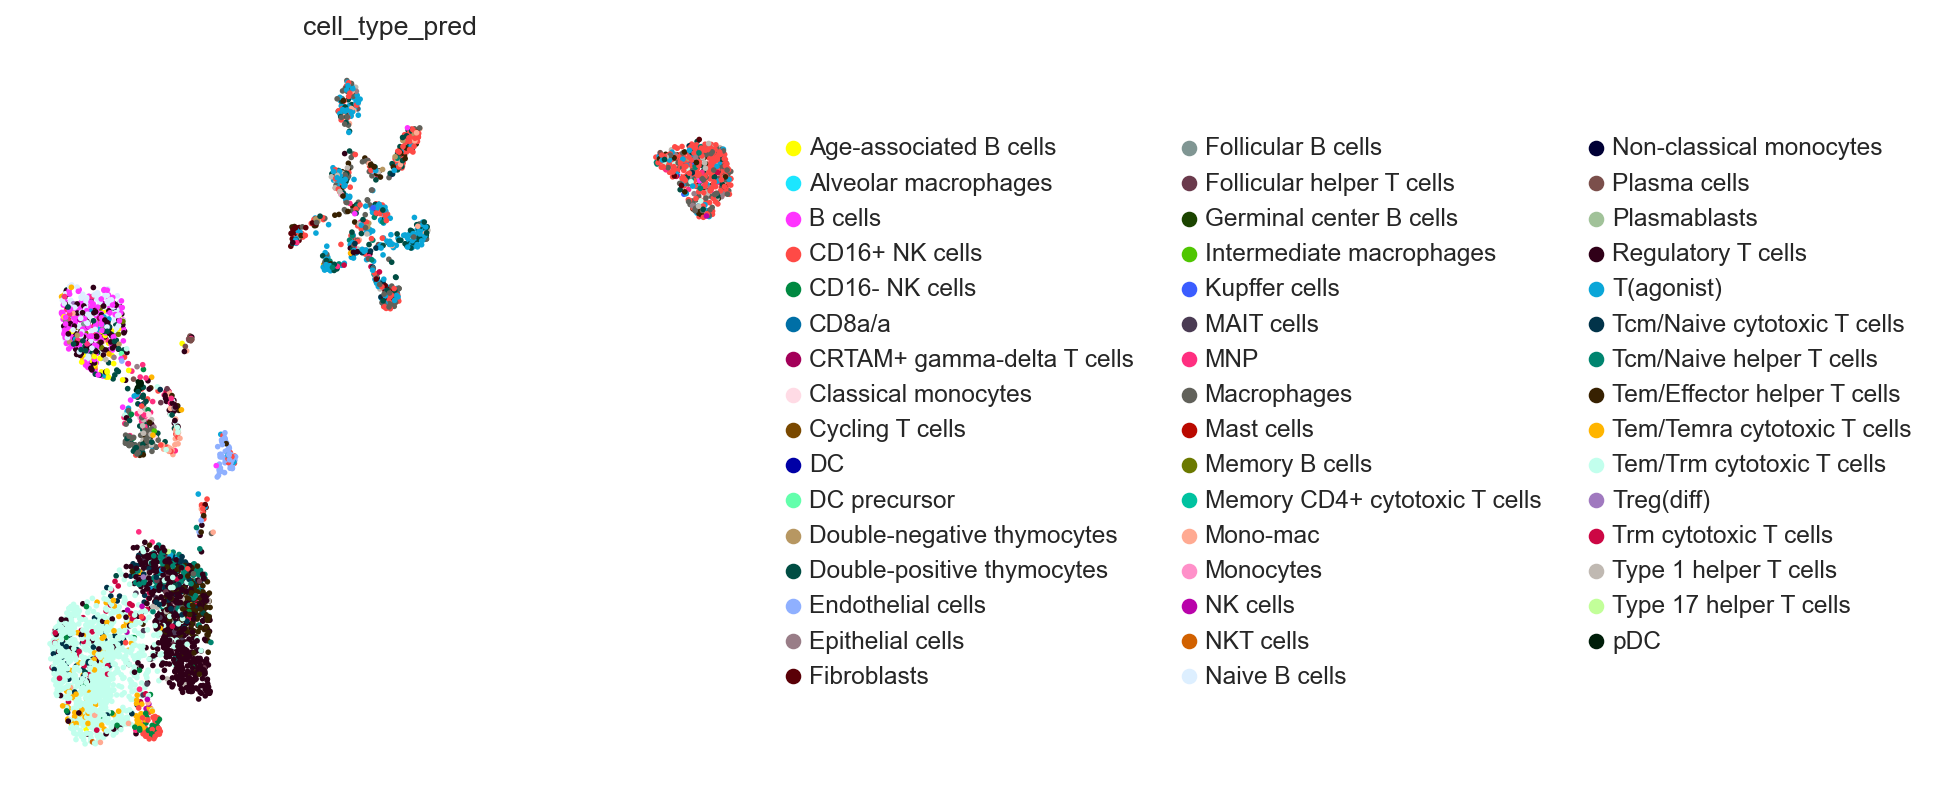

In [43]:
sc.pl.umap(adata, color="cell_type_pred")

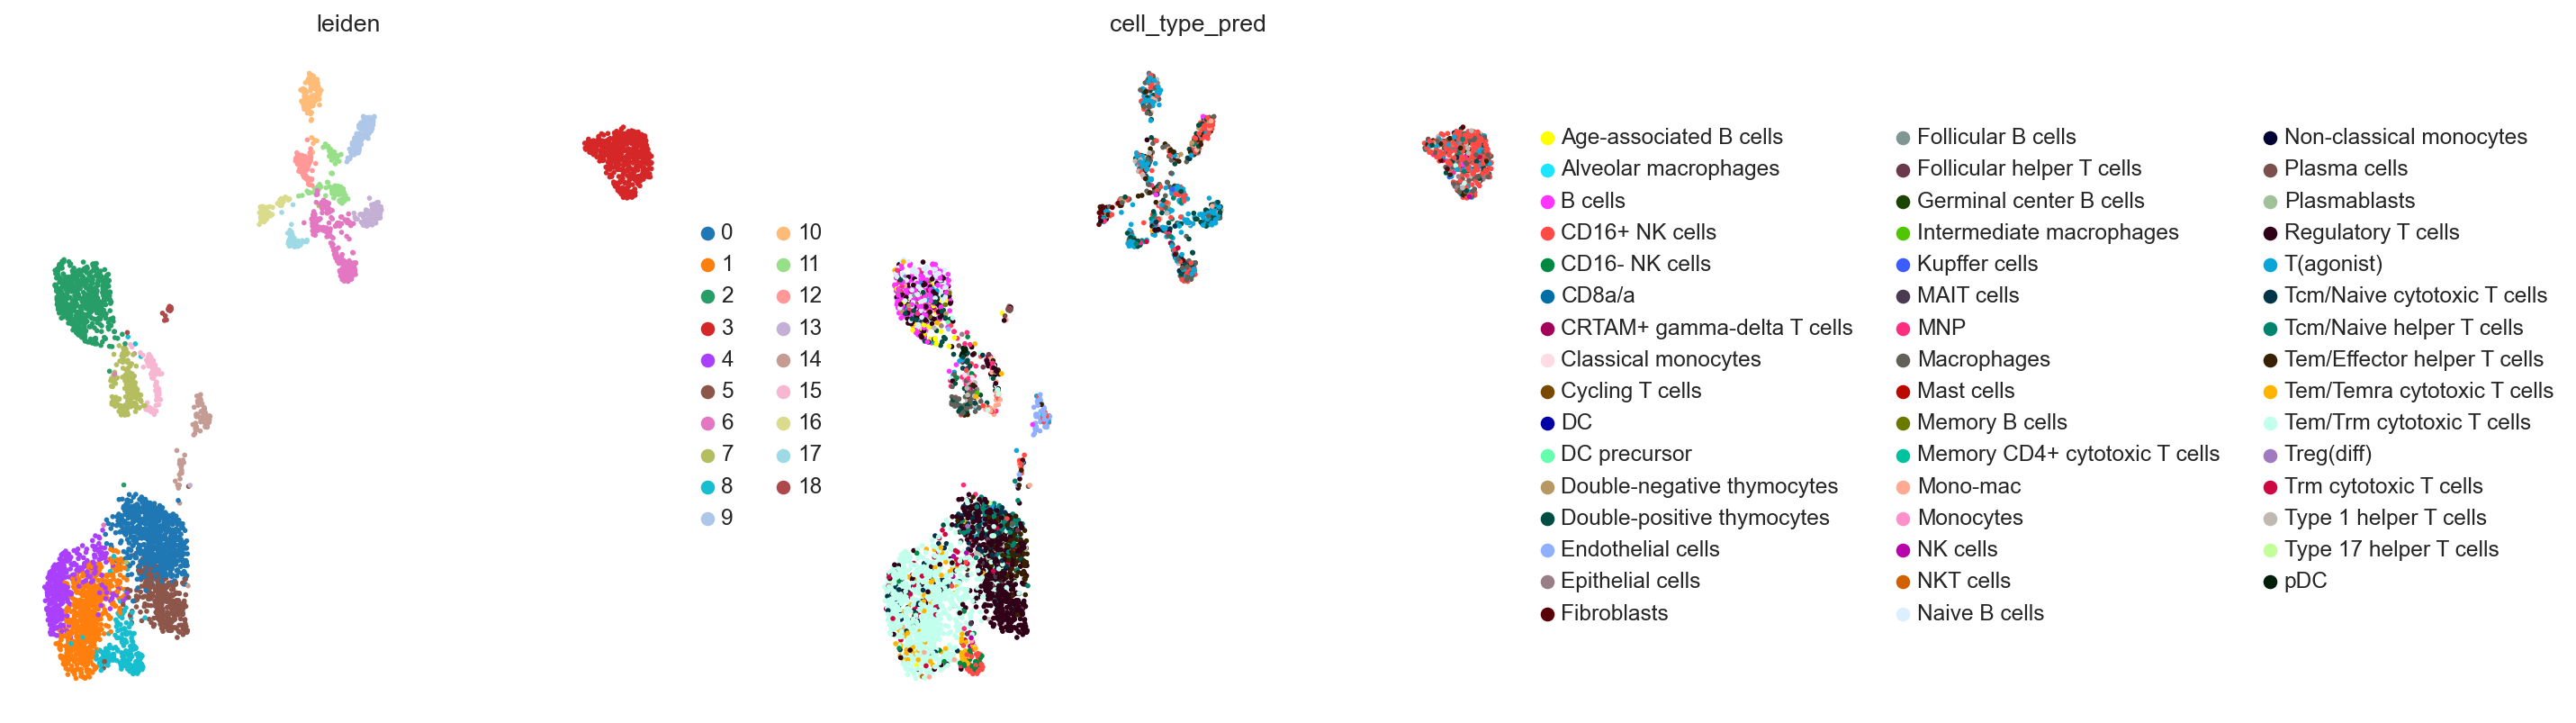

In [44]:
sc.pl.umap(adata, color=["leiden","cell_type_pred"])

In [45]:
cluster_labels = (
    adata.obs.groupby("leiden")["cell_type_pred"]
    .agg(lambda x: x.value_counts().index[0])
)

adata.obs["cluster_annotation"] = adata.obs["leiden"].map(cluster_labels)

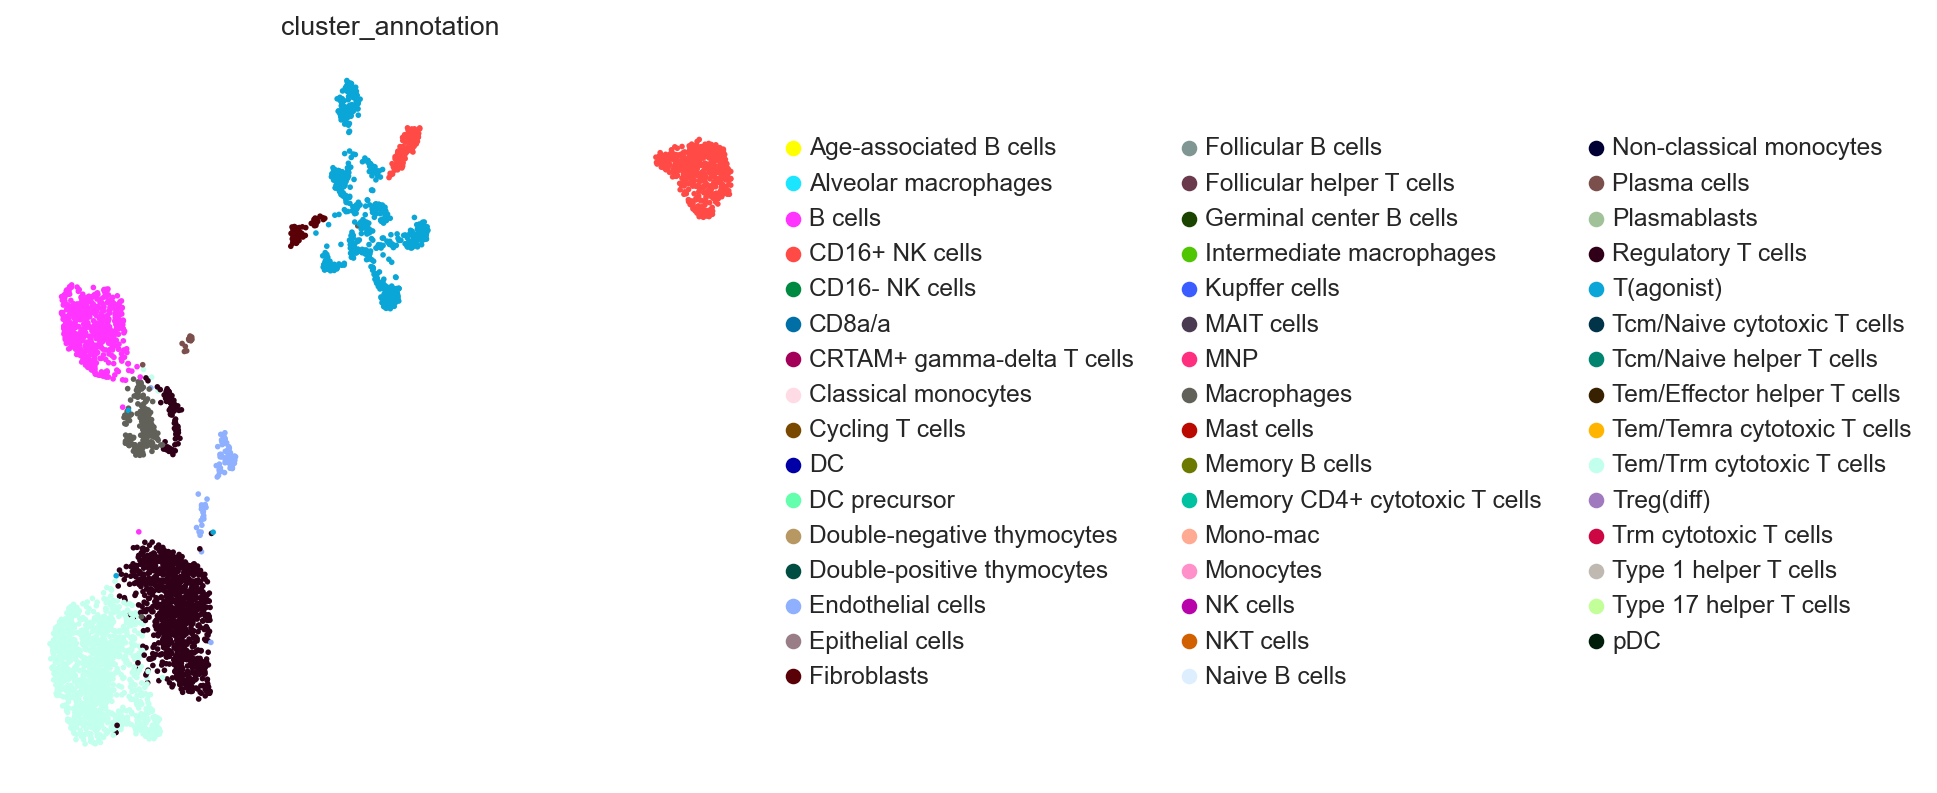

In [46]:
sc.pl.umap(adata, color="cluster_annotation")

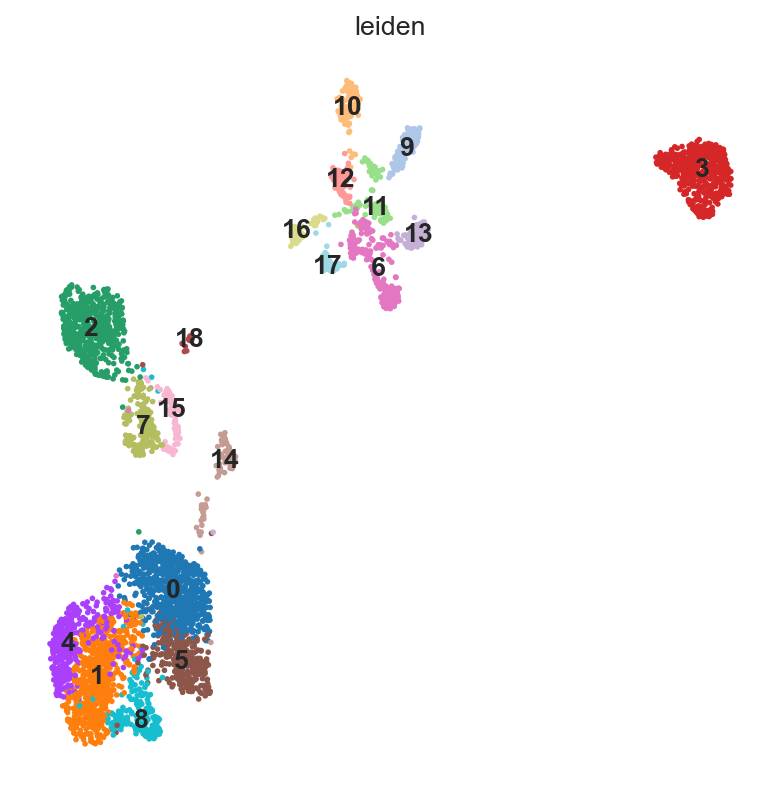

In [51]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data"
)

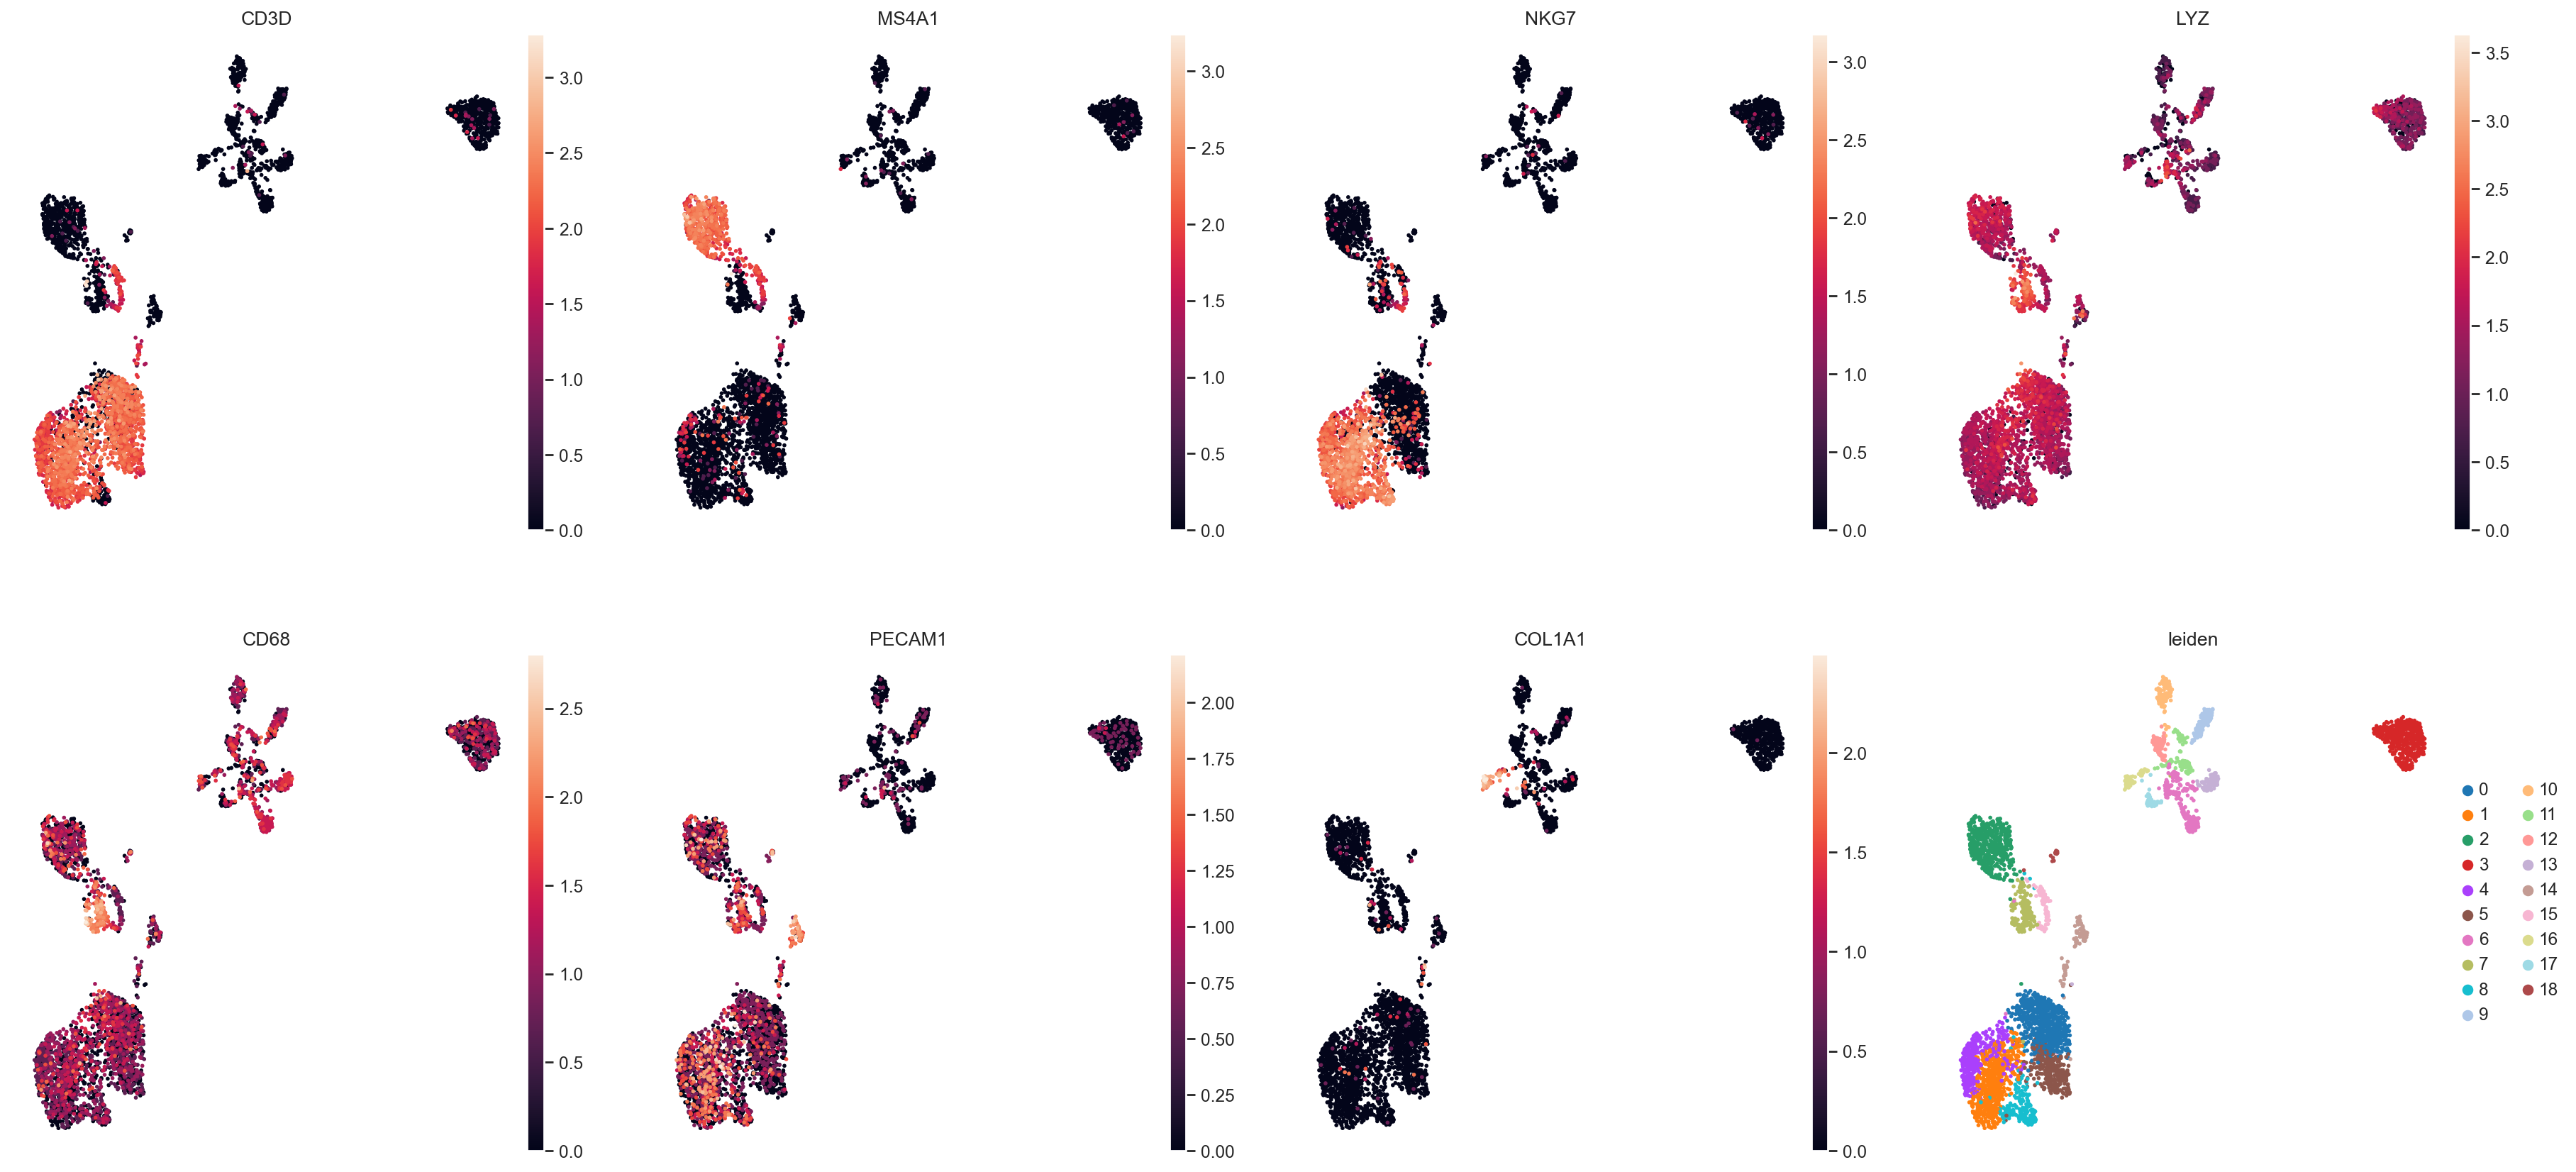

In [50]:
sc.pl.umap(adata, color=["CD3D","MS4A1","NKG7","LYZ", "CD68", "PECAM1", "COL1A1", "leiden"])

In [ ]:
# | Cell type   | Markers    |
# | ----------- | ---------- |
# | T cell      | CD3D, CD3E |
# | B cell      | MS4A1      |
# | NK cell     | NKG7, GNLY |
# | Macrophage  | LYZ, CD68  |
# | Endothelial | PECAM1     |
# | CAF         | COL1A1     |


In [ ]:
cluster_annotation = {
    "0": "T_cell",
    "1": "NK_cell",
    "2": "Macrophage",
    "3": "NK_cell",
    "4": "Endothelial",
    "5": "CAF"
}

In [ ]:
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_annotation)